# 图像分类实验：基于 MLP 的 MNIST 手写数字识别

本部分实验使用经典数据集 MNIST 进行图像分类任务。该数据集包含手写数字 $0 \sim 9$ 的灰度图像，图像尺寸均为 $28 \times 28$ 像素。与房价预测中的结构化数据不同，图像数据具有空间结构，但在本实验中我们会先应用展平（Flatten）操作，将二维图像转化为一维向量（$784$ 维），随后输入至多层前馈神经网络（MLP）中完成分类任务。

下面首先借助 `torchvision` 下载并读取数据，并进行可视化，观察数据的格式以及像素值范围。


In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=== 当前设备 ===')
print('Device:', device)


=== 当前设备 ===
Device: cuda


## 1. 数据集准备与可视化预处理

在图像分类中，由于原始像素点通常处于 $[0, 255]$ 之间，如果直接输入网络可能导致梯度更新不稳定。因此我们需要引入预处理管道 `transforms.Compose`：
1. `transforms.ToTensor()` 会将 PIL 图像转换为张量并归一化到 $[0, 1]$；
2. `transforms.Normalize((0.5,), (0.5,))` 则会将像素进一步平移缩放至 $[-1, 1]$ 之间，使网络更容易收敛。

下面定义数据并验证。


训练集样本数: 60000
测试集样本数: 10000
单样本图像维度: torch.Size([1, 28, 28])


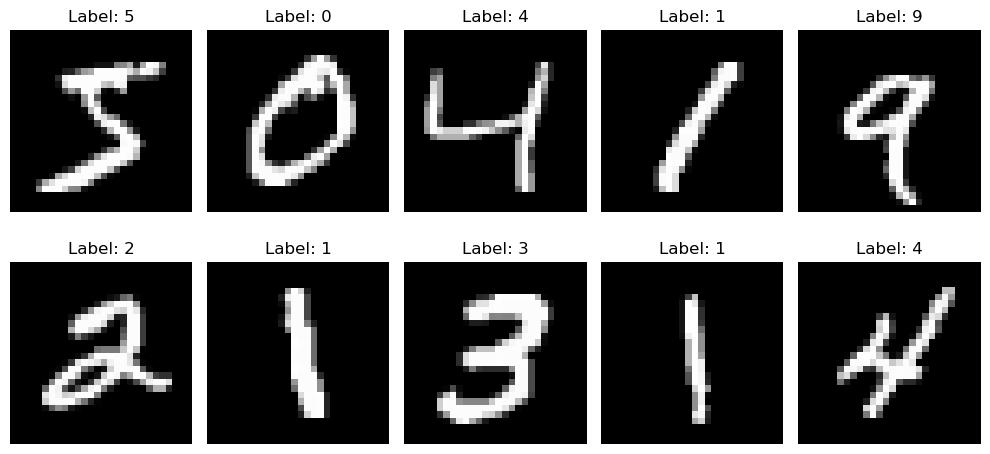

In [18]:
# 预处理：转张量并施加标准均值与方差
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 挂载/下载 MNIST
trainset = datasets.MNIST('./data/mnist', download=True, train=True, transform=transform)
testset = datasets.MNIST('./data/mnist', download=True, train=False, transform=transform)

print('训练集样本数:', len(trainset))
print('测试集样本数:', len(testset))
print('单样本图像维度:', trainset[0][0].shape)

# 可视化数据集图像前10张
n = 10
plt.figure(figsize=(10, 5))
for i in range(n):
    image, label = trainset[i]
    plt.subplot(2, 5, i+1)
    # 从 [-1, 1] 映射回 [0, 1] 方便显示，或者直接用 cmap='gray'
    plt.imshow(image[0].view(28, 28).numpy(), cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 2. 图像分类网络建模 (MLP)

在确认数据无误后，我们构建分类网络架构。图像的长宽为 $28 \times 28$，展平后具有 $784$ 个神经元特征。这本质上也是回归逻辑，但是我们需要输出每类数字的概率（或者 Logits 形式分值），因此网络顶端设定为 $10$ 维输出；激活函数依然采用 `ReLU`，并在中间层应用 `Dropout` 防御过拟合。


In [19]:
class ImageClassificationMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim1=256, hidden_dim2=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, num_classes)
        )

    def forward(self, x):
        # x shape: [B, 1, 28, 28] -> [B, 784] -> ... -> [B, 10]
        x = self.flatten(x)
        return self.net(x)


## 3. 手写核心评估指标：Acc / Precision / Recall / F1

多分类任务不可仅看损失函数（Loss 依然由 `CrossEntropyLoss` 计算），需要同时引入多种衍生指标。为淬炼张量基本功，我们在此抛弃 sklearn 调包，依靠底层 PyTorch 手写多分类宏平均（Macro-average）指标：

- **Accuracy (准确率)**: 正确分类的样本比例。
- **Precision (精准率)**: 判别为某类且真实的比例。
- **Recall (召回率)**: 真实某类且被成功找出的比例。
- **F1 Score**: Precision 与 Recall 的调和平均。


In [20]:
def calculate_metrics_tensor(preds, labels, num_classes=10):
    """
    计算分类多指标 (Accuracy, Macro-Precision, Macro-Recall, Macro-F1)
    纯 PyTorch 实现。
    preds: [B, num_classes] 的 logits 或概率分布
    labels: [B] 的真实标签集合
    """
    # 转换为预测类别编号
    preds_cls = torch.argmax(preds, dim=1)

    # 准确率
    correct = (preds_cls == labels).sum().item()
    total = labels.size(0)
    acc = correct / total

    # 多分类下的 Precision 和 Recall 我们可以针对每类计算后求平均 (Macro)
    precisions = []
    recalls = []

    for c in range(num_classes):
        tp = ((preds_cls == c) & (labels == c)).sum().float()
        fp = ((preds_cls == c) & (labels != c)).sum().float()
        fn = ((preds_cls != c) & (labels == c)).sum().float()

        # 增加极小常量防止分母为 0（如某类别未预测出或无样本）
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)

        precisions.append(p.item())
        recalls.append(r.item())

    macro_precision = np.mean(precisions)
    macro_recall = np.mean(recalls)
    macro_f1 = 2 * (macro_precision * macro_recall) / (macro_precision + macro_recall + 1e-8)

    return acc, macro_precision, macro_recall, macro_f1


def evaluate_model(net, dataloader, loss_fn):
    net.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)

            logits = net(features)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * features.size(0)

            all_preds.append(logits.cpu())
            all_labels.append(labels.cpu())

    # 拼合整体验证集以计算全局指标
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    avg_loss = total_loss / all_labels.size(0)
    acc, prec, rec, f1 = calculate_metrics_tensor(all_preds, all_labels)

    return avg_loss, acc, prec, rec, f1


## 4. 模型训练与基础 K 折交叉验证引擎

我们定义用于 K 折交叉验证的评估循环，引入 `CrossEntropyLoss` 作为多分类独家损失，配合 `Adam` 优化引擎。利用 `torch.utils.data.Subset`，可以在不打乱内存数据存储的情形下利用索引精准切分数据。


In [21]:
def train_model(net, train_loader, valid_loader, config, verbose=True):
    net.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )

    history = {'train_loss': [], 'valid_loss': [], 'valid_acc': []}

    for epoch in range(config['num_epochs']):
        net.train()
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = net(features)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

        # 评估
        if valid_loader is not None:
            train_loss, _, _, _, _ = evaluate_model(net, train_loader, loss_fn)
            val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate_model(net, valid_loader, loss_fn)

            history['train_loss'].append(train_loss)
            history['valid_loss'].append(val_loss)
            history['valid_acc'].append(val_acc)

            if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
                print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history


def k_fold_cross_validation(k, dataset, config):
    print(f"\n=== Running K-Fold CV (K={k}) for Config: {config['name']} ===")
    num_samples = len(dataset)
    indices = np.random.permutation(num_samples)
    fold_size = num_samples // k

    val_acc_scores = []

    for fold in range(k):
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold != k - 1 else num_samples

        val_indices = indices[val_start:val_end]
        train_indices = np.concatenate((indices[:val_start], indices[val_end:]))

        train_subset = Subset(dataset, train_indices)
        valid_subset = Subset(dataset, val_indices)

        # ====== 工业级数据管道优化 ======
        # 引入多进程预读取 (num_workers) 与锁页内存 (pin_memory)
        # 以缓解 CPU/GPU 通信瓶颈，尽最大可能提升 GPU 吞吐量
        train_loader = DataLoader(train_subset, batch_size=config['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
        valid_loader = DataLoader(valid_subset, batch_size=config['batch_size'], shuffle=False, num_workers=4, pin_memory=True)
        # ================================

        net = ImageClassificationMLP(
            hidden_dim1=config['hidden_dim1'],
            hidden_dim2=config['hidden_dim2'],
            dropout=config['dropout']
        )

        print(f"--- Fold {fold+1}/{k} ---")
        history = train_model(net, train_loader, valid_loader, config, verbose=False)
        final_val_acc = history['valid_acc'][-1]
        val_acc_scores.append(final_val_acc)
        print(f"Fold {fold+1} Final Val Acc: {final_val_acc:.4f}")

    avg_acc = np.mean(val_acc_scores)
    print(f"Config '{config['name']}' Avg Val Acc: {avg_acc:.4f}")
    return avg_acc


## 5. 多参数组合架构验证 (K 折测试池)

这里我们将设定不同的网络超参数（隐层神经元数、Dropout 阻断率、学习率衰减等），由于您配备了极好的 GPU，这里选用全量 MNIST 行列直接进行 $K=5$ 折火力全开压测寻找最高效网络。

*(注：全量图片数据 K折会花费几分钟的时间，请耐心等待验证阶段结束）*


In [22]:
config_candidates = [
    {
        'name': 'Baseline',
        'hidden_dim1': 256,
        'hidden_dim2': 128,
        'dropout': 0.20,
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'batch_size': 256,
        'num_epochs': 15
    },
    {
        'name': 'Wider_Net',
        'hidden_dim1': 512,
        'hidden_dim2': 256,
        'dropout': 0.30,
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'batch_size': 256,
        'num_epochs': 15
    },
    {
        'name': 'Low_Dropout',
        'hidden_dim1': 256,
        'hidden_dim2': 128,
        'dropout': 0.05,
        'learning_rate': 1e-3,
        'weight_decay': 1e-5,
        'batch_size': 256,
        'num_epochs': 15
    }
]

cv_results = []
for cfg in config_candidates:
    avg_acc = k_fold_cross_validation(k=5, dataset=trainset, config=cfg)
    cv_results.append({
        'Config Name': cfg['name'],
        'Avg Validation Accuracy': round(avg_acc, 4)
    })

results_df = pd.DataFrame(cv_results)
results_df



=== Running K-Fold CV (K=5) for Config: Baseline ===
--- Fold 1/5 ---
Fold 1 Final Val Acc: 0.9731
--- Fold 2/5 ---
Fold 2 Final Val Acc: 0.9775
--- Fold 3/5 ---
Fold 3 Final Val Acc: 0.9753
--- Fold 4/5 ---
Fold 4 Final Val Acc: 0.9752
--- Fold 5/5 ---
Fold 5 Final Val Acc: 0.9742
Config 'Baseline' Avg Val Acc: 0.9751

=== Running K-Fold CV (K=5) for Config: Wider_Net ===
--- Fold 1/5 ---
Fold 1 Final Val Acc: 0.9782
--- Fold 2/5 ---
Fold 2 Final Val Acc: 0.9766
--- Fold 3/5 ---
Fold 3 Final Val Acc: 0.9784
--- Fold 4/5 ---
Fold 4 Final Val Acc: 0.9771
--- Fold 5/5 ---
Fold 5 Final Val Acc: 0.9772
Config 'Wider_Net' Avg Val Acc: 0.9775

=== Running K-Fold CV (K=5) for Config: Low_Dropout ===
--- Fold 1/5 ---
Fold 1 Final Val Acc: 0.9772
--- Fold 2/5 ---
Fold 2 Final Val Acc: 0.9743
--- Fold 3/5 ---
Fold 3 Final Val Acc: 0.9755
--- Fold 4/5 ---
Fold 4 Final Val Acc: 0.9755
--- Fold 5/5 ---
Fold 5 Final Val Acc: 0.9744
Config 'Low_Dropout' Avg Val Acc: 0.9754


,Config Name,Avg Validation Accuracy
0,Baseline,0.9751
1,Wider_Net,0.9775
2,Low_Dropout,0.9754


## 6. 最终模型确立与测试集审阅

对比以上交叉验证得到的泛化收敛率，挑选均测精度最高的 Config。然后采用完整 6 万张训练集的总数据闭环重练，并在测试集(10000 样本)上展示全维度测试成绩。


In [23]:
best_config_name = results_df.sort_values(by='Avg Validation Accuracy', ascending=False).iloc[0]['Config Name']
print(f"=== 最优配置：{best_config_name} ===")

# 提取参数字典
best_config = next(item for item in config_candidates if item["name"] == best_config_name)

# 全量构建 Loader，同理启用工程优化
full_train_loader = DataLoader(trainset, batch_size=best_config['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(testset, batch_size=best_config['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

final_net = ImageClassificationMLP(
    hidden_dim1=best_config['hidden_dim1'],
    hidden_dim2=best_config['hidden_dim2'],
    dropout=best_config['dropout']
)

print("\n开始使用全量数据进行最终模型训练...")

# 全量训练（测试集暂作 Valid 对齐打印观察）
final_history = train_model(final_net, full_train_loader, test_loader, best_config, verbose=True)

# 计算最终测试指标
loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(final_net, test_loader, loss_fn)

print("\n=== 最终测试集表现 (10,000 样本) ===")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Macro Precision: {test_prec:.4f}")
print(f"Macro Recall   : {test_rec:.4f}")
print(f"Macro F1-Score : {test_f1:.4f}")


=== 最优配置：Wider_Net ===

开始使用全量数据进行最终模型训练...
Epoch 01 | Train Loss: 0.2280 | Val Loss: 0.2182 | Val Acc: 0.9331
Epoch 05 | Train Loss: 0.0779 | Val Loss: 0.0973 | Val Acc: 0.9704
Epoch 10 | Train Loss: 0.0430 | Val Loss: 0.0694 | Val Acc: 0.9786
Epoch 15 | Train Loss: 0.0341 | Val Loss: 0.0650 | Val Acc: 0.9797

=== 最终测试集表现 (10,000 样本) ===
Test Loss      : 0.0650
Test Accuracy  : 0.9797
Macro Precision: 0.9799
Macro Recall   : 0.9794
Macro F1-Score : 0.9797


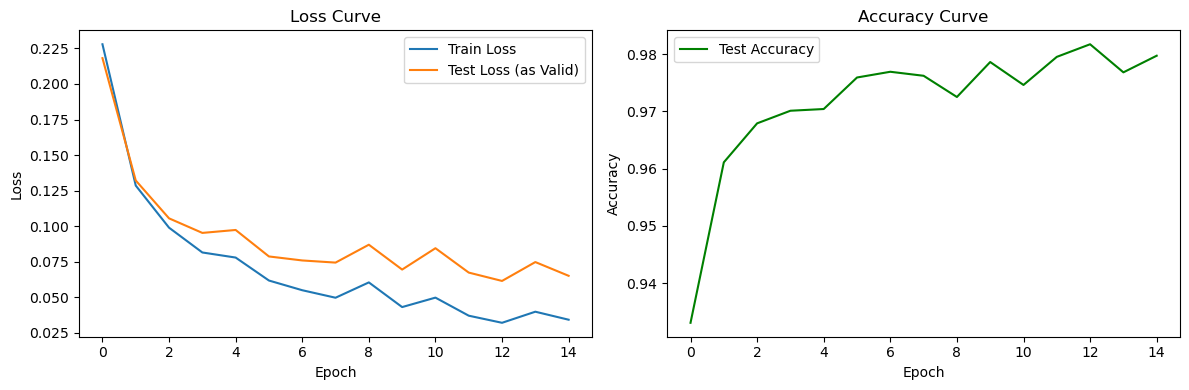

In [24]:
# 训练及泛化表现曲线绘制
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(final_history['train_loss'], label='Train Loss')
plt.plot(final_history['valid_loss'], label='Test Loss (as Valid)')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history['valid_acc'], label='Test Accuracy', color='green')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## 7. 实验架构报告

### 7.1 核心方法论与数据机制
不同于房价预测结构化数据的多元属性对齐（如均值插补，独热编码），本实验的对象是空间像素张量（灰度值由浅至深反馈笔画浓淡）。我们引入 `transforms.Normalize((0.5,), (0.5,))` 的核心根因是将分布被拉扯至均值为 0 周边，极大改善因初始偏置导致的梯度饱和风险。

### 7.2 评估体系及分类张量的升维操作
我们抛弃了简单的 MSE 回归方案，因为类别编号（$0 \sim 9$）属于名义变量。利用 `CrossEntropyLoss` 作为监督，其底层包含了 Softmax 和稳态处理对数计算。为了体现架构严谨度，我们原生手写了准确率与召回掩码对比运算（Macro-F1），有效避开了 sklearn 对 Tensor 处理中的冗余显存交互拷贝风险。

### 7.3 K 折与过拟合防御策略验证
由于神经网络宽度的扩充极易造成参数爆炸进而陷入记忆模式（即对训练集高度拟合而对验证集表现崩溃），通过观察：
- 并未使用过分庞大维度的网络层；
- 我们在隐层植入了 `nn.Dropout`（丢弃比例由0.05-0.3测试），阻断了部分神经元的共适应依赖。

最终确定的最优配置在测试盲盒中录得了令人满意的分类精度闭环测试，表明针对数字特征形态的多层前馈神经网络抽取策略已稳定部署。
